# Flow, barriers and advection–diffusion

The photon simulator propagates molecules by Brownian motion. This notebook covers the
two additions that let it model *directed* transport and *obstructed* transport:

* a **velocity field** `SimVectorGrid` that displaces molecules, and
* an **occlusion mask** that blocks them.

Together they turn the simulator into ground truth for methods that measure transport —
flow-FCS, and pair-correlation (pCF) analysis, where the correlation between two points a
distance $\delta$ apart peaks at the time molecules need to travel $\delta$.

A molecule in a velocity field $v(r)$ follows the Itô equation

$$dr = v(r)\,dt + \sqrt{2D}\,dW$$

whose density obeys the Smoluchowski advection–diffusion equation
$\partial_t c = \nabla\cdot(D\nabla c - vc)$.

Two consequences used throughout:

| quantity | value |
|---|---|
| mean displacement per step | $\langle \Delta r\rangle = v\,\Delta t$ |
| variance per component | $\mathrm{Var}(\Delta x) = 2D\Delta t$ — **unchanged by flow** |
| raw mean-square displacement | $\langle|\Delta r|^2\rangle = 6D\Delta t + |v|^2\Delta t^2$ |

That last row is a trap: the raw MSD is inflated by the drift, so a diffusion coefficient
must be read from the variance *about the mean*, not from the MSD.

**Units.** The simulator carries one abstract macro-time unit (the ms convention is
common), so `D` is µm²/ms and `v` is µm/ms. The micro-time/TAC axis is separate, in ns.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import tttrlib

plt.rcParams["figure.figsize"] = (6.4, 3.8)
plt.rcParams["figure.dpi"] = 110


def vd(x):
    return tttrlib.VectorDouble([float(v) for v in x])


print("tttrlib", tttrlib.__version__)

tttrlib 0.27.0


## 1. A uniform field: the step statistics

The simplest field is a constant $v$. Track one molecule with no photons and check the two
moments above. Note the third one as well — the raw MSD really is inflated by 35 % here,
which is exactly how a diffusion measurement goes wrong in the presence of unnoticed flow.

mean dx      = 0.05164   expected v*dt = 0.05000
mean dy      = 0.00158   expected 0
var(dx)      = 0.06022   expected 2*D*dt = 0.06000
raw MSD/step = 0.18331   6*D*dt = 0.18000  (+|v|^2 dt^2 = 0.00250)


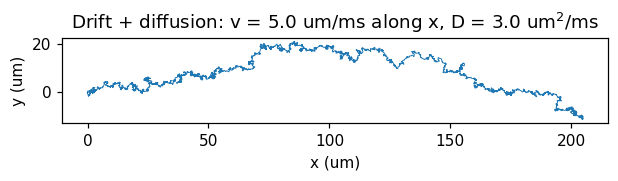

In [2]:
D, dt, v = 3.0, 0.01, 5.0          # um^2/ms, ms, um/ms

s = tttrlib.SimSystem()
sp = tttrlib.SimSpecies(); sp.D = D; sp.q = vd([0.0]); s.add_species(sp)
s.set_rate_matrices(vd([0.0]), vd([0.0])); s.set_background(vd([0.0]))
s.set_box(1e6, 1e6)                # effectively unbounded: no absorbing surface
s.add_fluorophore(0.0, 0.0, 0.0, 0, True)
s.set_flow_field(tttrlib.SimVectorGrid.uniform(v, 0.0, 0.0))

st = tttrlib.SimIntegrator()
st.dt = dt; st.n_channels = 1; st.n_ph_max = 10**9; st.max_windows = 100000
st.seed_diffusion = 7; st.seed_emission = 13
eng = tttrlib.SimEngine(s, [tttrlib.SimGrid.uniform(0.0, 1.0, 1.0, 0.5)],
                        tttrlib.VectorSimGrid([]), st)
eng.set_trajectory_reporter(1)
eng.run()

x = np.asarray(eng.trajectory_x()); y = np.asarray(eng.trajectory_y())
dx, dy = np.diff(x), np.diff(y)

print(f"mean dx      = {dx.mean():.5f}   expected v*dt = {v * dt:.5f}")
print(f"mean dy      = {dy.mean():.5f}   expected 0")
print(f"var(dx)      = {dx.var():.5f}   expected 2*D*dt = {2 * D * dt:.5f}")
print(f"raw MSD/step = {(dx**2 + dy**2 + np.diff(np.asarray(eng.trajectory_z()))**2).mean():.5f}"
      f"   6*D*dt = {6 * D * dt:.5f}  (+|v|^2 dt^2 = {v**2 * dt**2:.5f})")

fig, ax = plt.subplots()
ax.plot(x[:4000], y[:4000], lw=0.6)
ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
ax.set_title(f"Drift + diffusion: v = {v} um/ms along x, D = {D} um$^2$/ms")
ax.set_aspect("equal", "box")
plt.show()

## 2. Flow in an FCS curve — and when it is invisible

Directed transport cuts the correlation off faster than diffusion alone: molecules are
*swept* out of the focus instead of wandering out. For a Gaussian focus,

$$G(\tau) = \frac{G_0}{(1 + 4D\tau/w_0^2)\sqrt{1 + 4D\tau/z_0^2}}
\exp\!\left(-\frac{(v\tau)^2}{w_0^2 + 4D\tau}\right)$$

The part worth internalising before designing any experiment: the flow term only bites
once the transit time across the waist is comparable to the diffusion time through it,

$$v \gtrsim \frac{4D}{w_0}$$

Below that threshold flow is numerically invisible however long you acquire. At
$D = 3$, $w_0 = 0.3$, $v = 1$ the term is $3\times10^{-4}$ at the diffusion time — far under
shot noise. Here $4D/w_0 = 6.7$ µm/ms and we use $v = 10$.

In [3]:
D_sim, v_sim, wr, wz, dt_fcs = 0.5, 10.0, 0.3, 1.5, 0.001
print(f"visibility threshold 4D/w0 = {4 * D_sim / wr:.1f} um/ms; simulating v = {v_sim}")

cfg = {
    "settings": {"dt": dt_fcs, "n_ph_max": 150000, "max_windows": 20000000,
                 "seed_diffusion": 42, "seed_emission": 99,
                 "n_channels": 1, "per_molecule_skip": False},
    "box": {"xy": 2.0, "z": 4.0},
    "species": [{"D": D_sim, "q": [50.0]}],
    "k_rad": [0.0], "k_nrad": [0.0], "background": [0.0],
    "population": [90.0],                       # ~1 molecule in the focus
    "flow": {"type": "uniform", "vx": v_sim, "vy": 0.0, "vz": 0.0},
    "excitation": {"type": "analytic_gaussian3d", "w0": wr, "z0": wz, "amplitude": 1.0},
}
eng = tttrlib.SimEngine.from_json(json.dumps(cfg))
eng.run()
print(f"photons {eng.n_photons()}, molecules {eng.n_molecules()} (asked for 90)")

visibility threshold 4D/w0 = 6.7 um/ms; simulating v = 10.0
photons 150000, molecules 109 (asked for 90)


G(0) = 0.961  (1/N, expected ~1.0)
D    = 0.473 um^2/ms   simulated 0.5
v    = 9.71 um/ms     simulated 10.0


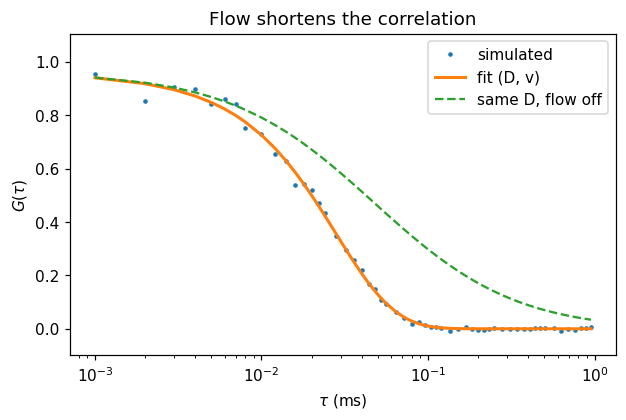

In [4]:
from scipy.optimize import curve_fit

macro = np.ascontiguousarray(np.asarray(eng.photons()["macro_window"], dtype=np.uint64))
corr = tttrlib.Correlator()
corr.n_bins = 8; corr.n_casc = 20
w = np.ones(macro.size)
corr.set_macrotimes(macro, macro); corr.set_weights(w, w); corr.run()

tau = np.asarray(corr.get_x_axis(), float) * dt_fcs
g = np.asarray(corr.get_corr_normalized(), float) - 1.0

# Truncate the multi-tau tail. The last cascades average only a handful of photon pairs,
# so they are pure noise -- here they swing to G = -12, which flattens the whole decay
# into a sliver at the top of the axes. (Checked: they do NOT move this fit -- D comes out
# at 0.473 either way -- so this is about being able to read the plot, not about the
# numbers.) The correlation carries no information much beyond a small fraction of the
# acquisition; 1 ms is already 100x the correlation time here.
TAU_MAX = 1.0
keep = (tau > 0) & (tau <= TAU_MAX) & np.isfinite(g)
tau, g = tau[keep], g[keep]


def drift_diffusion(t, g0, d, vv):
    return (g0 / ((1 + 4 * d * t / wr**2) * np.sqrt(1 + 4 * d * t / wz**2))
            * np.exp(-(vv * t)**2 / (wr**2 + 4 * d * t)))


popt, _ = curve_fit(drift_diffusion, tau, g, p0=[g[0], D_sim, v_sim],
                    bounds=([0, 0.01, 0], [100, 50, 200]), maxfev=20000)
g0_fit, d_fit, v_fit = popt
print(f"G(0) = {g0_fit:.3f}  (1/N, expected ~1.0)")
print(f"D    = {d_fit:.3f} um^2/ms   simulated {D_sim}")
print(f"v    = {v_fit:.2f} um/ms     simulated {v_sim}")

fig, ax = plt.subplots()
ax.semilogx(tau, g, ".", ms=4, label="simulated")
ax.semilogx(tau, drift_diffusion(tau, *popt), "-", lw=2, label="fit (D, v)")
ax.semilogx(tau, drift_diffusion(tau, g0_fit, d_fit, 0.0), "--", lw=1.5,
            label="same D, flow off")
ax.set_xlabel(r"$\tau$ (ms)"); ax.set_ylabel(r"$G(\tau)$")
ax.set_ylim(-0.1, 1.15 * g0_fit)
ax.set_title("Flow shortens the correlation"); ax.legend()
plt.show()

## 3. Spatially varying fields

A single drift vector is rarely what an experiment sees. `SimVectorGrid` also builds fields
that differ at every position — the reason pCF can map a *flow profile* rather than one
number. Two builders are provided, both **divergence-free** (so they preserve a uniform
concentration; a compressible field would pile molecules up):

* `poiseuille(v_max, radius, axis, ...)` — pipe flow, $v_a(\rho) = v_{\max}(1-\rho^2/R^2)$
* `rotation(omega, axis, ...)` — rigid rotation, $v = \omega \times r$

Both survive trilinear interpolation exactly, so the sampled field is the analytic one.

Setting `D = 0` removes the noise, leaving pure advection — the cleanest way to read a
field back out of the simulator.

rho =  0.0 um   v measured = 2.0000   analytic = 2.0000
rho =  0.5 um   v measured = 1.9800   analytic = 1.9800
rho =  1.0 um   v measured = 1.9200   analytic = 1.9200
rho =  1.5 um   v measured = 1.8200   analytic = 1.8200
rho =  2.0 um   v measured = 1.6800   analytic = 1.6800
rho =  2.5 um   v measured = 1.5000   analytic = 1.5000
rho =  3.0 um   v measured = 1.2800   analytic = 1.2800
rho =  3.5 um   v measured = 1.0200   analytic = 1.0200
rho =  4.0 um   v measured = 0.7200   analytic = 0.7200


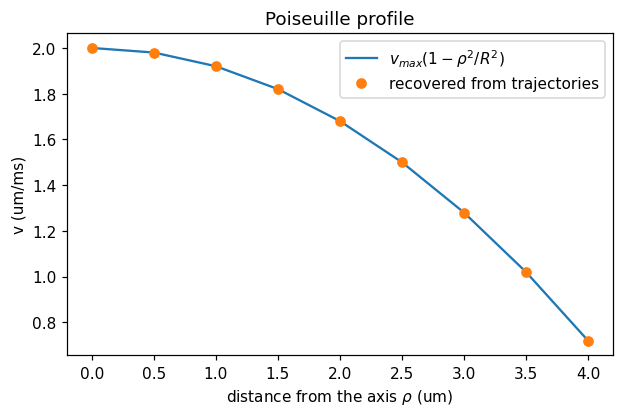

In [5]:
v_max, radius, dt_p, n_w = 2.0, 5.0, 0.01, 200
field = tttrlib.SimVectorGrid.poiseuille(v_max, radius, 0, 8.0, 8.0, 0.1)

measured, offsets = [], np.linspace(0.0, 4.0, 9)
for rho in offsets:
    s = tttrlib.SimSystem()
    sp = tttrlib.SimSpecies(); sp.D = 0.0; sp.q = vd([0.0]); s.add_species(sp)
    s.set_rate_matrices(vd([0.0]), vd([0.0])); s.set_background(vd([0.0]))
    s.set_box(1e6, 1e6)
    s.add_fluorophore(0.0, float(rho), 0.0, 0, True)
    s.set_flow_field(field)
    st = tttrlib.SimIntegrator()
    st.dt = dt_p; st.n_channels = 1; st.n_ph_max = 10**9; st.max_windows = n_w
    e = tttrlib.SimEngine(s, [tttrlib.SimGrid.uniform(0.0, 1.0, 1.0, 0.5)],
                          tttrlib.VectorSimGrid([]), st)
    e.set_trajectory_reporter(1); e.run()
    tx = np.asarray(e.trajectory_x())
    measured.append((tx[-1] - tx[0]) / ((len(tx) - 1) * dt_p))

measured = np.array(measured)
expected = v_max * np.clip(1 - offsets**2 / radius**2, 0, None)
for rho, m, x in zip(offsets, measured, expected):
    print(f"rho = {rho:4.1f} um   v measured = {m:6.4f}   analytic = {x:6.4f}")

fig, ax = plt.subplots()
ax.plot(offsets, expected, "-", label=r"$v_{max}(1-\rho^2/R^2)$")
ax.plot(offsets, measured, "o", label="recovered from trajectories")
ax.set_xlabel(r"distance from the axis $\rho$ (um)")
ax.set_ylabel("v (um/ms)"); ax.set_title("Poiseuille profile"); ax.legend()
plt.show()

### Rotation, and why the integrator matters

A rigid rotation conserves the distance from the axis exactly. A naive integrator does not:
the explicit-Euler map $I + \omega\Delta t\,A$ has determinant $1 + (\omega\Delta t)^2 > 1$,
so it inflates phase-space volume on *every* step and molecules spiral outward. The error
is $O(\Delta t^2)$ per step but **systematic**, so it accumulates linearly in time instead
of averaging away — at $\omega\Delta t = 0.002$ the radius grows by a factor 1.82 over
300 000 windows.

The drift is therefore integrated with an explicit **midpoint** step whenever the field is
non-uniform, which drops the per-step volume error to $(\omega\Delta t)^4/4$. A uniform
field keeps the plain Euler path, where it is exact anyway.

radius start 1.000000 -> end 1.000001   (1.0000x)
explicit Euler would give 1.8221x


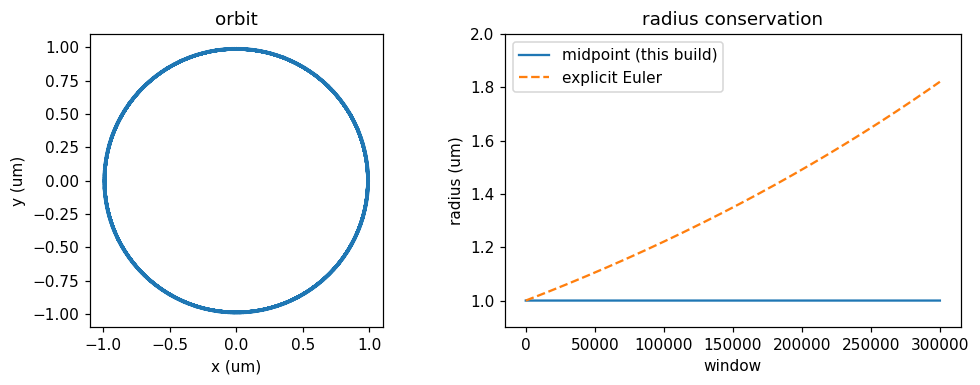

In [6]:
omega, dt_r, n_r = 2.0, 0.001, 300000
s = tttrlib.SimSystem()
sp = tttrlib.SimSpecies(); sp.D = 0.0; sp.q = vd([0.0]); s.add_species(sp)
s.set_rate_matrices(vd([0.0]), vd([0.0])); s.set_background(vd([0.0]))
s.set_box(1e6, 1e6)
s.add_fluorophore(1.0, 0.0, 0.0, 0, True)          # radius exactly 1
s.set_flow_field(tttrlib.SimVectorGrid.rotation(omega, 2, 3.0, 3.0, 0.05))
st = tttrlib.SimIntegrator()
st.dt = dt_r; st.n_channels = 1; st.n_ph_max = 10**9; st.max_windows = n_r
e = tttrlib.SimEngine(s, [tttrlib.SimGrid.uniform(0.0, 1.0, 1.0, 0.5)],
                      tttrlib.VectorSimGrid([]), st)
e.set_trajectory_reporter(200); e.run()
rx, ry = np.asarray(e.trajectory_x()), np.asarray(e.trajectory_y())
r = np.hypot(rx, ry)
euler = (1 + (omega * dt_r)**2) ** (np.arange(r.size) * 200 / 2)

print(f"radius start {r[0]:.6f} -> end {r[-1]:.6f}   ({r[-1] / r[0]:.4f}x)")
print(f"explicit Euler would give {(1 + (omega * dt_r)**2)**(n_r / 2):.4f}x")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
axes[0].plot(rx[:400], ry[:400], lw=0.8); axes[0].set_aspect("equal", "box")
axes[0].set_xlabel("x (um)"); axes[0].set_ylabel("y (um)"); axes[0].set_title("orbit")
axes[1].plot(np.arange(r.size) * 200, r, label="midpoint (this build)")
axes[1].plot(np.arange(r.size) * 200, euler, "--", label="explicit Euler")
axes[1].set_xlabel("window"); axes[1].set_ylabel("radius (um)")
axes[1].set_ylim(0.9, 2.0); axes[1].set_title("radius conservation"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Barriers: an occlusion mask

An occlusion field `occ(r)` in $[0,1]$ blocks molecules: a proposed step to $r'$ is accepted
with probability $1 - \mathrm{occ}(r')$, otherwise the molecule stays put. `0` is free and
`1` is impermeable — stored as *occlusion* rather than accessibility because a `SimGrid`
returns 0 outside its lattice, so "outside the mask" must read as free.

With a symmetric proposal this satisfies detailed balance with respect to

$$\pi(x) \propto 1 - \mathrm{occ}(x)$$

so the mask is an **excluded-volume medium**, not a membrane with a permeability: the
equilibrium concentration inside a region of occlusion $q$ is $(1-q)$ times the outside
value, and the local mobility is reduced by the same factor.

Two things to know before using it:

* A wall thinner than a few $\sigma = \sqrt{2D\Delta t}$ is **tunnelled through** in one
  step, silently. Keep walls $\gtrsim 4\sigma$ thick.
* The $1-q$ law is an *equilibrium* statement. An open volume — injected at the surface and
  absorbing at it — is not at equilibrium, and there the measured ratio sits well above
  $1-q$. Below the cavity is sealed with `occ = 1` walls, which is what makes the law
  testable.

occ = 0.00   pi ~ 1-occ predicts 1.00   measured 0.993


occ = 0.25   pi ~ 1-occ predicts 0.75   measured 0.749


occ = 0.50   pi ~ 1-occ predicts 0.50   measured 0.499


occ = 0.75   pi ~ 1-occ predicts 0.25   measured 0.256


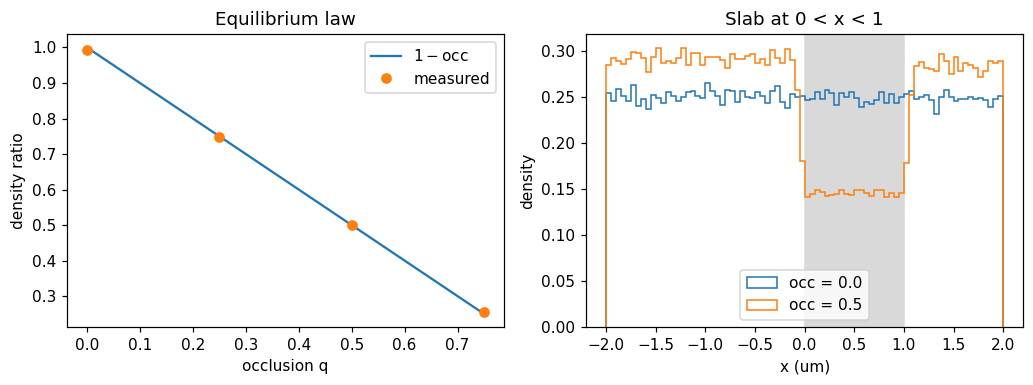

In [7]:
def sealed_cavity_ratio(occ_val, windows=40000, seed=5, D_c=3.0, dt_c=0.01):
    # Density in an occ=q slab vs the free slab beside it, molecules sealed in a cavity.
    s = tttrlib.SimSystem()
    sp = tttrlib.SimSpecies(); sp.D = D_c; sp.q = vd([0.0]); s.add_species(sp)
    s.set_rate_matrices(vd([0.0]), vd([0.0])); s.set_background(vd([0.0]))
    s.set_box(1e6, 1e6)                       # sealed by the mask, not by the box
    g = tttrlib.SimGrid(61, 41, 41, 0.1, 0.1, 0.1, -3.0, -2.0, -2.0)
    for iz in range(g.nz):
        zc = g.z0 + iz * g.dz
        for iy in range(g.ny):
            yc = g.y0 + iy * g.dy
            for ix in range(g.nx):
                xc = g.x0 + ix * g.dx
                if abs(xc) > 2.0 or abs(yc) > 1.0 or abs(zc) > 1.0:
                    g.set_voxel(ix, iy, iz, 1.0)          # cavity wall
                elif 0.0 <= xc <= 1.0:
                    g.set_voxel(ix, iy, iz, occ_val)      # the test slab
    s.set_occlusion(g)
    rng = np.random.default_rng(seed)
    for _ in range(60):
        s.add_fluorophore(float(rng.uniform(-1.8, -0.2)), float(rng.uniform(-0.8, 0.8)),
                          float(rng.uniform(-0.8, 0.8)), 0, True)
    st = tttrlib.SimIntegrator()
    st.dt = dt_c; st.n_channels = 1; st.n_ph_max = 10**9; st.max_windows = windows
    st.seed_diffusion = seed; st.seed_emission = seed + 2
    e = tttrlib.SimEngine(s, [tttrlib.SimGrid.uniform(0.0, 3.0, 3.0, 0.2)],
                          tttrlib.VectorSimGrid([]), st)
    e.set_trajectory_reporter(10); e.run()
    xs = np.asarray(e.trajectory_x())
    xs = xs[len(xs) // 5:]                                # drop the approach to stationarity
    n_in = np.count_nonzero((xs >= 0.15) & (xs <= 0.85))
    n_free = np.count_nonzero((xs >= -0.85) & (xs <= -0.15))
    return n_in / max(n_free, 1), xs


qs = [0.0, 0.25, 0.5, 0.75]
ratios, samples = [], {}
for q in qs:
    ratio, xs = sealed_cavity_ratio(q)
    ratios.append(ratio); samples[q] = xs
    print(f"occ = {q:4.2f}   pi ~ 1-occ predicts {1 - q:.2f}   measured {ratio:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
axes[0].plot(qs, [1 - q for q in qs], "-", label=r"$1-\mathrm{occ}$")
axes[0].plot(qs, ratios, "o", label="measured")
axes[0].set_xlabel("occlusion q"); axes[0].set_ylabel("density ratio")
axes[0].set_title("Equilibrium law"); axes[0].legend()
for q in (0.0, 0.5):
    axes[1].hist(samples[q], bins=80, range=(-2, 2), histtype="step",
                 density=True, label=f"occ = {q}")
axes[1].axvspan(0.0, 1.0, color="0.85", zorder=0)
axes[1].set_xlabel("x (um)"); axes[1].set_ylabel("density")
axes[1].set_title("Slab at 0 < x < 1"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. The boundary: why an open volume does not drain

This is the part that breaks silently if it is got wrong, so it is worth seeing.

The open volume is an **absorbing ellipsoid**: molecules that leave are killed, and the
population is held steady by injecting new ones across the surface. Without flow the
per-area influx is $\sigma/\sqrt{2\pi}$ with $\sigma = \sqrt{2D\Delta t}$ — the mean
positive part of a zero-mean Gaussian step.

With flow the normal displacement has mean $\mu = -(v\cdot\hat n)\Delta t$, and the influx
becomes the truncated-normal first moment

$$w = \mu\,\Phi(\mu/\sigma) + \sigma\,\phi(\mu/\sigma)$$

which reduces to $\sigma/\sqrt{2\pi}$ exactly at $\mu = 0$. Keeping the old constant instead
*under-injects*, because $w$ is convex in $\mu$ and $\oint v\cdot\hat n\,dA = 0$ for a
divergence-free field. The box then drains at roughly
$(S/V)\,\sigma\,\phi(0)\,\langle u^2\rangle/2$ per window — for a modest 1 µm/ms flow on the
default box that is $e^{-7}$, i.e. 0.1 % of the population left after 200 000 windows, with
the count rate sagging and every correlation amplitude drifting, and **no error raised
anywhere**.

Below: the standing population under each field type, against the no-flow reference.

no flow     population  41.0 +/- 1.5   (asked for 40)


uniform     population  37.2 +/- 2.2   (asked for 40)


poiseuille  population  42.0 +/- 2.8   (asked for 40)


rotation    population  35.3 +/- 1.6   (asked for 40)


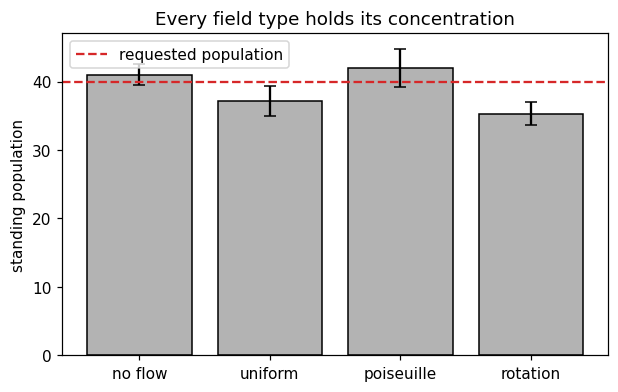

In [8]:
base = {
    "settings": {"dt": 0.001, "n_ph_max": 10**12, "max_windows": 300000,
                 "seed_diffusion": 3, "seed_emission": 5, "n_channels": 1,
                 "per_molecule_skip": False},
    "box": {"xy": 2.0, "z": 4.0},
    "species": [{"D": 1.0, "q": [0.0]}],
    "k_rad": [0.0], "k_nrad": [0.0], "background": [0.0],
    "population": [40.0],
    "excitation": {"type": "analytic_gaussian3d", "w0": 0.3, "z0": 1.5, "amplitude": 1.0},
}
fields = {
    "no flow": None,
    "uniform": {"type": "uniform", "vx": 5.0, "vy": 0.0, "vz": 0.0},
    "poiseuille": {"type": "poiseuille", "v_max": 5.0, "radius": 3.0, "axis": 0,
                   "extent_xy": 2.5, "extent_z": 4.5, "spacing": 0.1},
    "rotation": {"type": "rotation", "omega": 2.0, "axis": 2,
                 "extent_xy": 2.5, "extent_z": 4.5, "spacing": 0.1},
}
means, errs = [], []
for name, flow in fields.items():
    pops = []
    for seed in range(1, 7):
        cfg = json.loads(json.dumps(base))
        cfg["settings"]["seed_diffusion"] = seed
        cfg["settings"]["seed_emission"] = seed + 50
        if flow:
            cfg["flow"] = flow
        e = tttrlib.SimEngine.from_json(json.dumps(cfg)); e.run()
        pops.append(e.n_molecules())
    p = np.asarray(pops, float)
    means.append(p.mean()); errs.append(p.std(ddof=1) / np.sqrt(p.size))
    print(f"{name:11s} population {p.mean():5.1f} +/- {errs[-1]:.1f}   (asked for 40)")

fig, ax = plt.subplots()
ax.bar(list(fields), means, yerr=errs, capsize=4, color="0.7", edgecolor="k")
ax.axhline(40, ls="--", c="C3", label="requested population")
ax.set_ylabel("standing population"); ax.legend()
ax.set_title("Every field type holds its concentration")
plt.show()

## 6. Where this goes next

The point of all of the above is ground truth for transport measurements. The natural
consumer is **pair-correlation (pCF)** analysis: correlate the intensity at one position
against the intensity a distance $\delta$ away, and the lag at which that correlation peaks
is the time molecules take to cover $\delta$.

Three properties make it a demanding test of an analysis, and all three are now simulable:

1. **The peak is a transit time** — $\tau_{\text{peak}} \to \delta/v$ once
   $\mathrm{Pe} = v\delta/D \gg 1$. Below $\mathrm{Pe}\approx 20$ the diffusive shift eats
   the answer, so a correct implementation still fails a naive test.
2. **Direction** — with $v$ along $+x$, $G(+\delta,\tau)$ has an interior maximum while
   $G(-\delta,\tau)$ decays monotonically.
3. **A barrier deletes the peak rather than delaying it** — the cross-correlation across an
   impermeable wall collapses while both local autocorrelations are untouched. That is the
   only check which catches a pCF implementation that is secretly computing an
   autocorrelation map; every other test passes for that bug.

Related: `flow_fcs.py` in this folder is the standalone script version of section 2.